## Population-Based Structural Health Monitoring (PBSHM)

### Objective
Detect whether a structure is damaged using measurement-like features and graph structure.

## Dataset Overview
- 50 structures
- Each has 4–8 storeys
- Structure Features:
  - Structure id (`structure_id`)
  - Number of Storeys (`n_storeys`)
  - Edges (`edges`)
  - Node Features (`n_features`)
  - Feature Names (`feature_names`)

- Node features:
  - Storey (`storey`)
  - height (`height_m`)
  - dominant modal frequency (`dominant_modal_frequency_Hz`)

- Available Structure Labels:
  - Structure id (`structure_id`)
  - Damaged (`damaged`)
  - Damage Storey (`damage_storey`)

In [2]:
"""
Imprting necessary libraries and setting up the environment 
for data analysis and visualization.
"""

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from collections import Counter

plt.style.use('seaborn')

## Load the Data

In [3]:
# Load structures
with open("structures_measurements.json") as f:
    structures = json.load(f)

# Load labels
labels = pd.read_csv("structure_labels.csv")

# Load population graph
edges = pd.read_csv("population_edges_geometry.csv")
weights = pd.read_csv("population_edge_weights_geometry.csv")

# Metadata (optional)
with open("population_metadata.json") as f:
    metadata = json.load(f)

## Basic Dataset Inspections

In [21]:
n_structures = len(structures)
print(f"Total Number of Structures = {n_structures}.\n",)

# Displaying the first few rows of the labels and edges dataframes
print("//------------------------------------------------------//\n")
print("Structure Labels DataFrame:")
print(labels.head(), "\n")
print("//------------------------------------------------------//\n")
print("Population Edges and Geometry DataFrame:")
print(edges.head())
print("//------------------------------------------------------//\n")

Total Number of Structures = 50.

//------------------------------------------------------//

Structure Labels DataFrame:
   structure_id  damaged  damage_storey
0             0        0            NaN
1             1        0            NaN
2             2        0            NaN
3             3        1            0.0
4             4        1            4.0 

//------------------------------------------------------//

Population Edges and Geometry DataFrame:
   source  target
0       0       8
1       0      24
2       0      43
3       0      21
4       0      44
//------------------------------------------------------//



In [24]:

print("Population Edges, Weights and Geometry DataFrame:")
print(weights.head())

print("//------------------------------------------------------//\n")
# A sample of the structures
sample_structure = structures[0]
print("One Sample Structure (First Entry):")
sample_structure

Population Edges, Weights and Geometry DataFrame:
   source  target  cosine_similarity
0       0       8           0.999699
1       0      24           0.999450
2       0      43           0.999000
3       0      21           0.998081
4       0      44           0.997975
//------------------------------------------------------//

One Sample Structure (First Entry):


{'structure_id': 0,
 'n_storeys': 6,
 'edges': [[0, 1], [1, 2], [2, 3], [3, 4], [4, 5]],
 'feature_names': ['height_m', 'dominant_modal_frequency_Hz'],
 'node_features': [{'storey': 0,
   'height_m': 3.532,
   'dominant_modal_frequency_Hz': 2.66633},
  {'storey': 1, 'height_m': 4.938, 'dominant_modal_frequency_Hz': 8.06059},
  {'storey': 2, 'height_m': 4.558, 'dominant_modal_frequency_Hz': 4.46783},
  {'storey': 3, 'height_m': 4.434, 'dominant_modal_frequency_Hz': 2.66633},
  {'storey': 4, 'height_m': 3.899, 'dominant_modal_frequency_Hz': 5.19604},
  {'storey': 5, 'height_m': 3.544, 'dominant_modal_frequency_Hz': 0.80764}]}

## Extract Data into Usable Format

In [43]:
all_nodes = []

for structure in structures:
    structures_id = structure['structure_id']
    n_storeys = structure['n_storeys']
    
    for node in structure['node_features']:
        #node_data = dict(zip(structure['feature_names'], node))
        node_data = {feature: node[feature] for feature in structure['feature_names']}
        node_data['storey'] = node['storey']
        node_data['structure_id'] = structures_id
        #node_data['height_m'] = node['height_m']
        #node_data['dominant_modal_frequency_Hz'] = node['dominant_modal_frequency_Hz']
        node_data['n_storeys'] = n_storeys
        all_nodes.append(node_data)

nodes_df = pd.DataFrame(all_nodes)

# Merge labels
nodes_df = nodes_df.merge(labels, on='structure_id')

In [58]:
nodes_df.head(7)

,height_m,dominant_modal_frequency_Hz,storey,structure_id,n_storeys,damaged,damage_storey
0,3.532,2.66633,0,0,6,0,NaN
1,4.938,8.06059,1,0,6,0,NaN
2,4.558,4.46783,2,0,6,0,NaN
3,4.434,2.66633,3,0,6,0,NaN
4,3.899,5.19604,4,0,6,0,NaN
5,3.544,0.80764,5,0,6,0,NaN
6,4.832,7.97649,0,1,5,0,NaN


## Explore Population Variation (EDA)

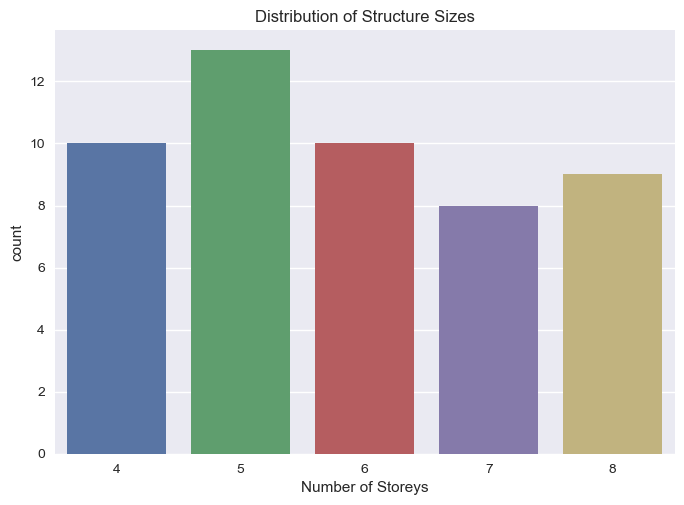

In [48]:
sns.countplot(x=[structure['n_storeys'] for structure in structures])
plt.title("Distribution of Structure Sizes")
plt.xlabel("Number of Storeys")
plt.show()

- 5 categories of stories, can be threated as a population clusterd based on structural hights, where we see if damage is related to a specific type of hights( Could be)

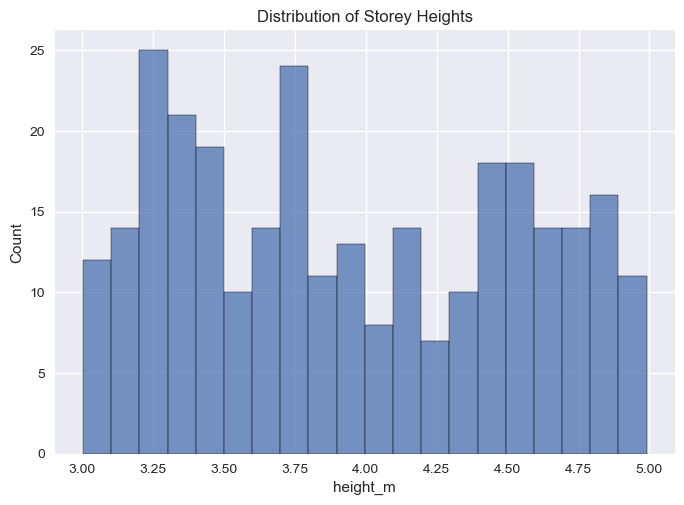

In [53]:
sns.histplot(nodes_df['height_m'], bins=20)
plt.title("Distribution of Storey Heights")
plt.show()

''' I need to cumulate the heights of the storeys to get the total height of each structure.'''

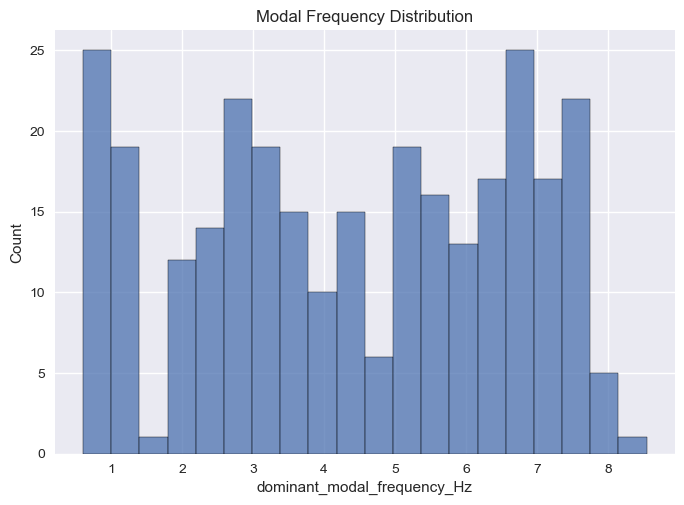

In [54]:
sns.histplot(nodes_df['dominant_modal_frequency_Hz'], bins=20)
plt.title("Modal Frequency Distribution")
plt.show()

'''I need to analyze the modal frequencies in relation to the 
structure sizes and heights so as to ubderstand which values 
(if hgher or lower dominant frequency) corelates more to damage. 
(check average, check frequency variation accros nodes of a story)'''

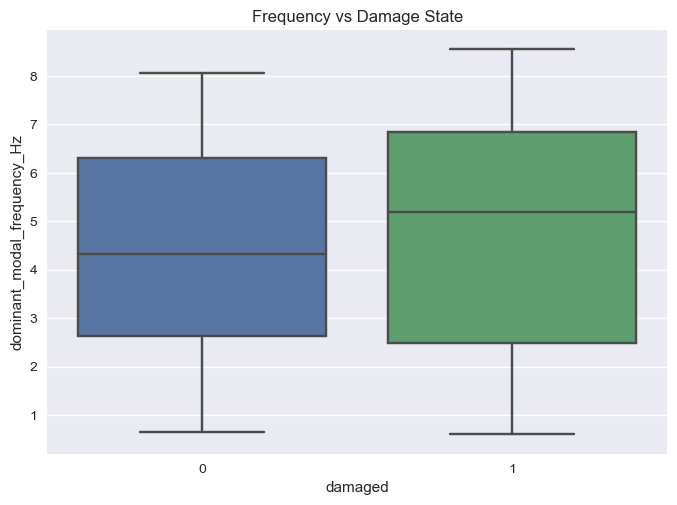

In [55]:
'''Compare Damaged vs Undamaged'''
sns.boxplot(
    data=nodes_df,
    x='damaged',
    y='dominant_modal_frequency_Hz'
)
plt.title("Frequency vs Damage State")
plt.show()

'''Add interpretation:

Damage → stiffness ↓ → frequency ↓ (physics insight!), 
Also observe that high variance in frequencies across 
nodes of a structure may indicate damage., think of it 
that at higher modes the structure tends to have different 
frequencies at different heights" usually refers to higher modes 
of vibration. While the fundamental frequency (1st mode) involves the whole building swaying back and forth like a single blade of grass, 
higher modes involve the building bending in multiple directions simultaneously 
(like an "S" shape or a zigzag)'''

Look at how hight and structures that experiences high variance / deviation correlates to damage
- Number of nodes and total hight relates to damage
- Number of nodes and frequency variation leads to damage

Corelation plot of: `Number of Storeys, Total hight, Frequency variation / deviation, damage` 

## Explore Graph Structure (Within Structures)

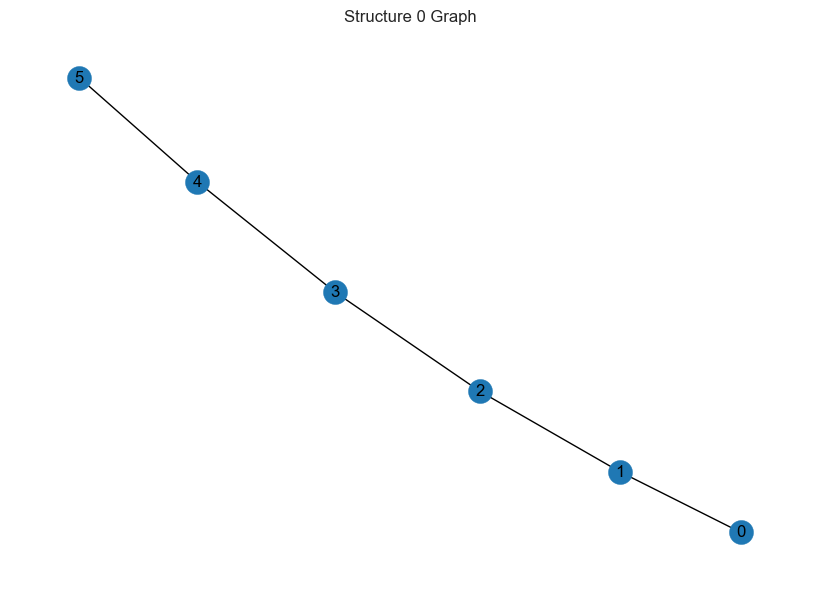

In [56]:
graph_structure = structures[0]

graph_img = nx.Graph()
graph_img .add_edges_from(graph_structure['edges'])

nx.draw(graph_img , with_labels=True)
plt.title(f"Structure {graph_structure['structure_id']} Graph")
plt.show()

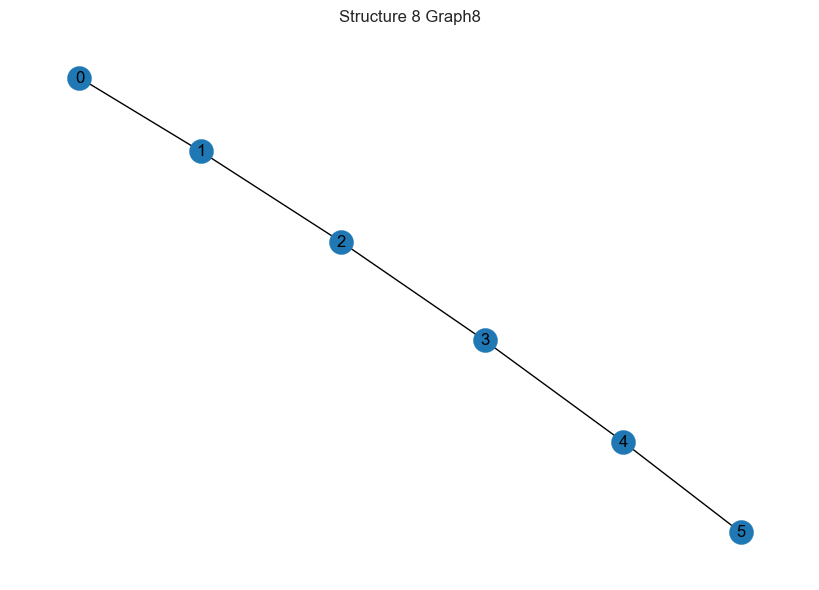

In [60]:
graph_structure8 = structures[8]

graph_img8 = nx.Graph()
graph_img8 .add_edges_from(graph_structure8['edges'])

nx.draw(graph_img8 , with_labels=True)
plt.title(f"Structure {graph_structure8['structure_id']} Graph8")
plt.show()

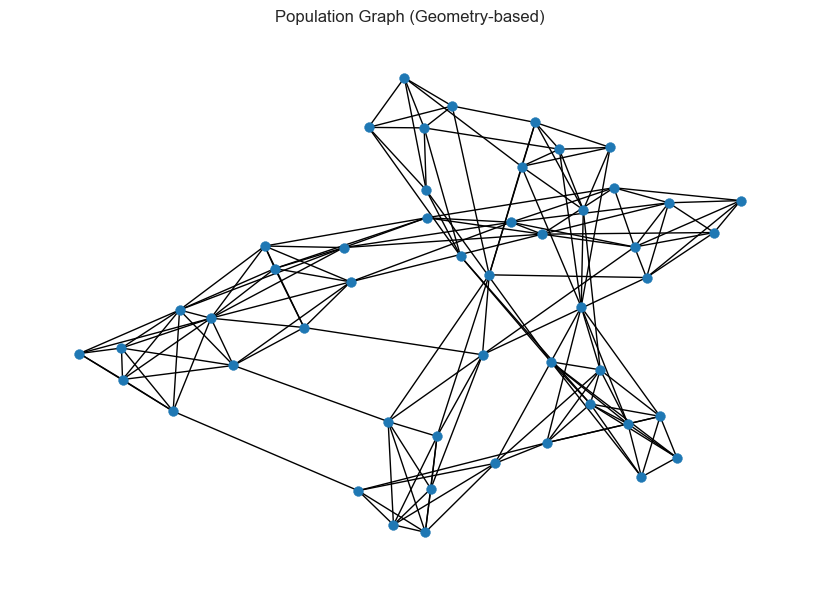

In [59]:
G_pop = nx.from_pandas_edgelist(edges, 'source', 'target')

nx.draw(G_pop, node_size=50)
plt.title("Population Graph (Geometry-based)")
plt.show()

Observe that structures are connected by:
Structures connected by similarity like, Story 0 and 8 are simillar based on number of stories
This enables population-based learning

## Frequency gradient (damage indicator)

In [70]:
nodes_df['freq_diff'] = nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'].diff()


In [79]:
nodes_df['abs_freq_diff'] = np.abs(nodes_df['freq_diff'])

In [71]:
'Makes structures comparable across sizes'
nodes_df['rel_height'] = nodes_df['height_m'] / nodes_df.groupby('structure_id')['height_m'].transform('max')


In [85]:
'Highlights abnormal nodes using frequency ratio'
nodes_df['freq_ratio'] = nodes_df['dominant_modal_frequency_Hz'] / nodes_df.groupby('structure_id')['dominant_modal_frequency_Hz'].transform('mean')

In [86]:
nodes_df['height_diff'] = nodes_df.groupby('structure_id')['height_m'].diff()

### Visualize Engineered Features

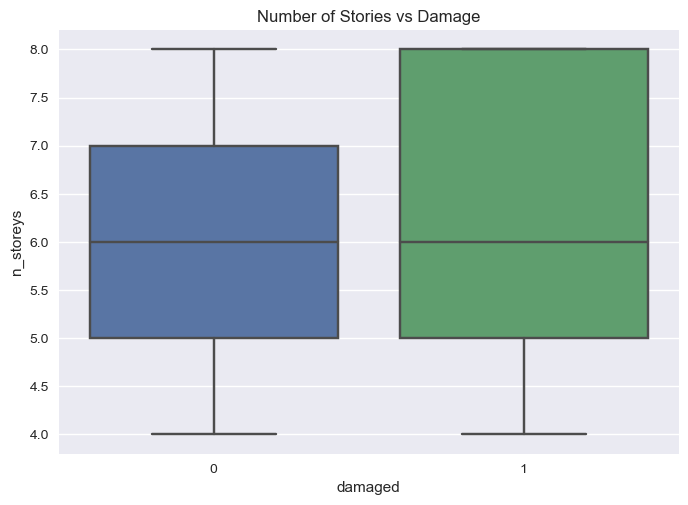

In [77]:
sns.boxplot(data=nodes_df, x='damaged', y='n_storeys')
plt.title("Number of Stories vs Damage")
plt.show()

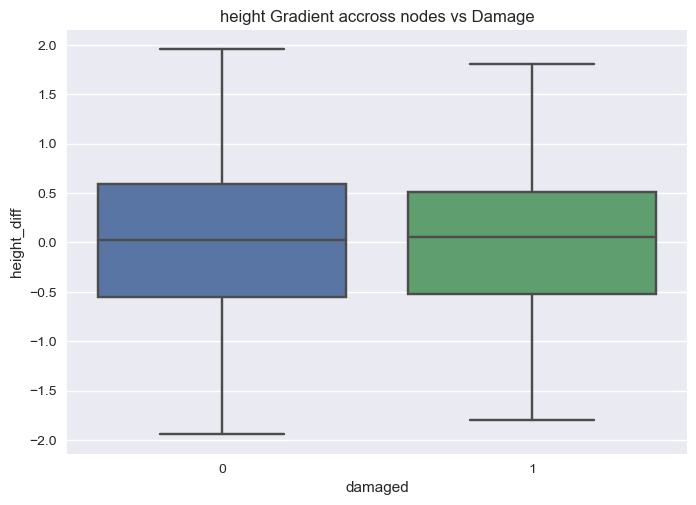

In [87]:
sns.boxplot(data=nodes_df, x='damaged', y='height_diff')
plt.title("height Gradient accross nodes vs Damage")
plt.show()

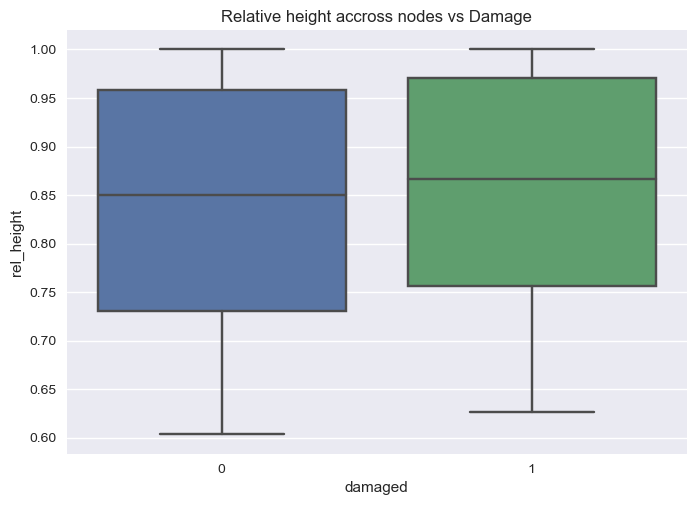

In [75]:
sns.boxplot(data=nodes_df, x='damaged', y='rel_height')
plt.title("Relative height accross nodes vs Damage")
plt.show()

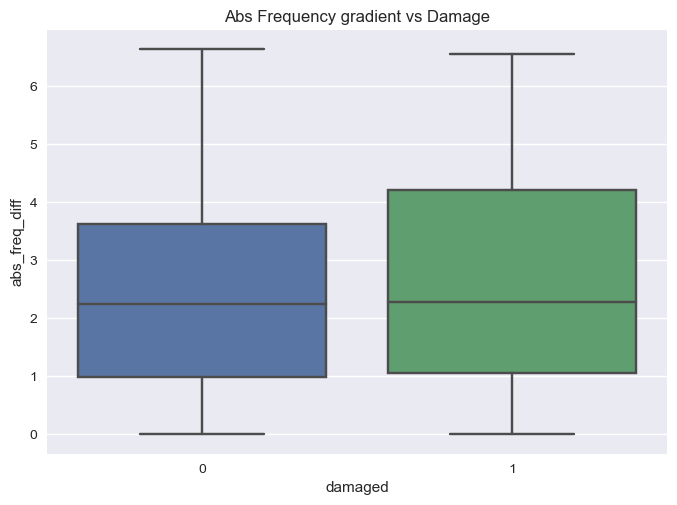

In [81]:
sns.boxplot(data=nodes_df, x='damaged', y='abs_freq_diff')
plt.title("Abs Frequency gradient vs Damage")
plt.show()

### Insight: Frequency Gradient vs Damage

The absolute frequency gradient shows significant overlap between damaged and undamaged structures, indicating limited discriminative power as a standalone feature.

However, damaged structures exhibit slightly higher variability, suggesting that damage introduces local irregularities rather than a consistent global shift.

This aligns with physical intuition: localized stiffness reduction may create irregular frequency patterns, but these effects are subtle and confounded by structural variability across the population.

Therefore, this feature is better suited as part of a combined feature set rather than used in isolation.

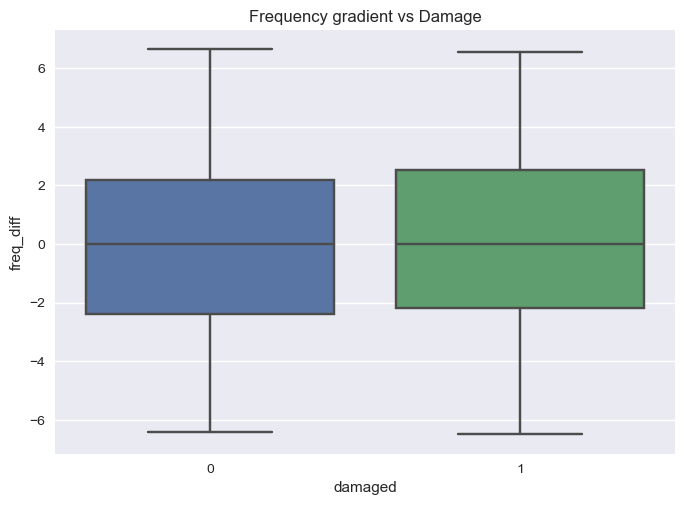

In [82]:
sns.boxplot(data=nodes_df, x='damaged', y='freq_diff')
plt.title("Frequency gradient vs Damage")
plt.show()

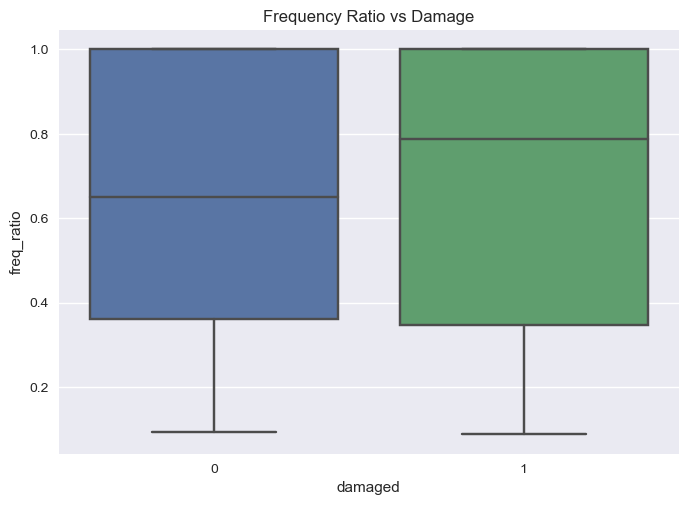

In [84]:
sns.boxplot(data=nodes_df, x='damaged', y='freq_ratio')
plt.title("Frequency Ratio vs Damage")
plt.show()

In [89]:
# Aggregate structure-level features including damage information
features_df = nodes_df.groupby('structure_id').agg(
    total_height=('height_m', 'sum'),
    dominant_frequency=('dominant_modal_frequency_Hz', lambda x: np.percentile(x, 75)),
    n_storeys=('n_storeys', 'first'),
    damaged=('damaged', 'first'),
    damage_storey=('damage_storey', 'first')
).reset_index()

features_df.head()

,structure_id,total_height,dominant_frequency,n_storeys,damaged,damage_storey
0,0,24.905,5.013987,6,0,NaN
1,1,19.219,6.937120,5,0,NaN
2,2,32.077,5.863805,8,0,NaN
3,3,22.181,7.486223,6,1,0.0
4,4,29.248,5.916205,7,1,4.0


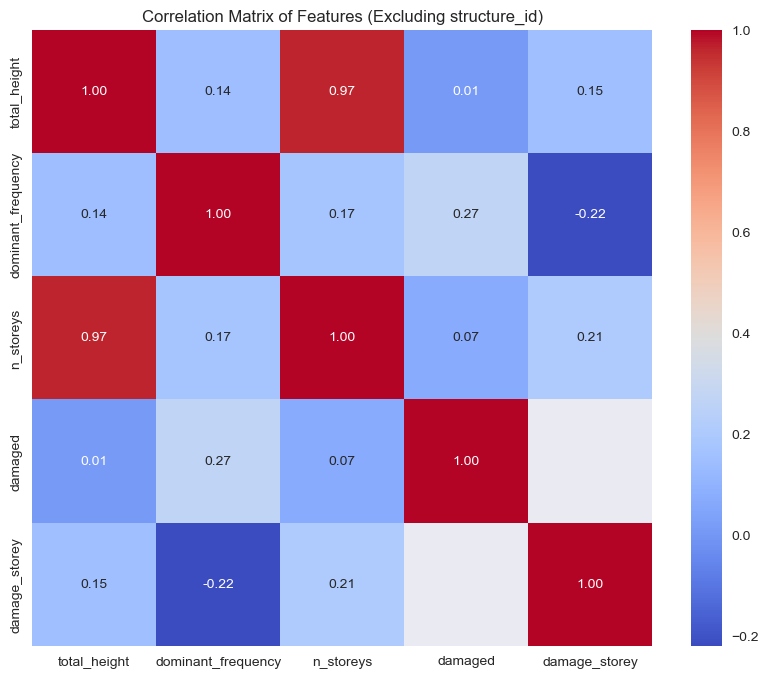

In [91]:
# Compute the correlation matrix without 'structure_id'
correlation_matrix = features_df.drop(columns=['structure_id']).corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Features (Excluding structure_id)")
plt.show()

Observations
- Frequency ratio greater than 1 = damaged
- Large spread between 25th and 75th percentiles = damage

Why not standard deviation or variance?
Both SD and variance are calculated using the mean, so they are sensitive to outliers and skewed distributions. If one structure has an unusually high or low frequency reading, it inflates the SD even if the bulk of the data is tightly clustered.
The IQR ignores the tails entirely — it only looks at the middle 50% of your data, which is exactly what you said you care about.

In the context of your PBSHM dataset specifically:
Each structure has 4–8 storey-level frequency readings. For each structure you can compute:
- `Q1 = np.percentile(freqs, 25)`
- `Q3 = np.percentile(freqs, 75)`
- `IQR = Q3 - Q1`
-
A damaged structure where one storey's stiffness is reduced will have one anomalously low frequency, pulling Q1 down and widening the IQR. A healthy structure should have a tighter, more uniform spread — smaller IQR.
This makes IQR a natural damage-sensitive feature for your dataset, and more robust than SD because:

SD would also be inflated by the damaged storey, but would be pulled further by any noise spike
IQR is resistant to that single outlier while still capturing the spread you care about
With only 4–8 values per structure, SD has high variance itself (small sample) — IQR is more stable